# 3D DEM manipulation 

Manipulating DEM is quite simple thanks to the use of several functions, depending on the needs. This can be useful for correcting certain shifts when they are known in advance.

In this page, we will show you how to properly do :
 - a simple translation with translate with :func:`~geoutils.Raster.translate`
 - a simple rotation (with a translation) with :func:`~xdem.coreg.apply_matrix`
 - a complex rotation (with a translation) with :func:`~xdem.coreg.matrix_from_translations_rotations` in :func:`~xdem.coreg.apply_matrix`


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import xdem

We load a DEM and crop it.

In [2]:
dem = xdem.DEM(xdem.examples.get_path("longyearbyen_ref_dem"))
dem = dem.icrop((100,100,200,200))

To translate a DEM by a shift (x, y, z) in CRS unit, we can use: 

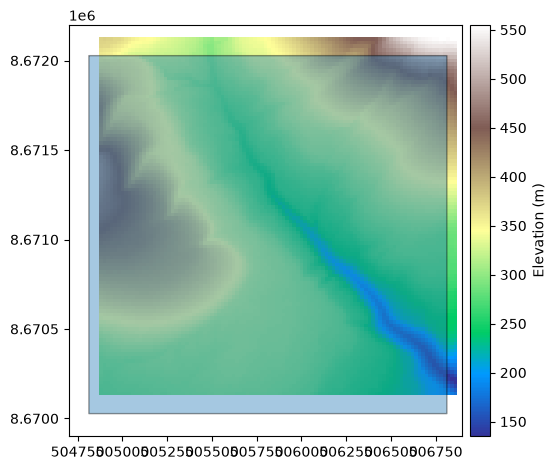

In [3]:
shift_x, shift_y, shift_z = (3 * dem.res[0], 5 * dem.res[1], 20)
dem_shifted = dem.translate(shift_x, shift_y) + shift_z 

dem_shifted.plot(cmap="terrain", cbar_title="Elevation (m)")
dem.get_footprint_projected(dem.crs, densify_points=5000).plot(ec="k", alpha=0.4)
plt.xlim(504700, 506900) 
plt.ylim(8669900, 8672200) 
plt.show()

Here the new DEM and the footprint of the original DEM. Note that the translation only updates the geotransform (no resampling is performed).

To perform a rotation, we need a transformation matrix. Here, a rotation of 0.6° in X (across-track) is attempted.

In [8]:
# Rotation matrix 3*3 
rotation = np.deg2rad(0.6)
rotation_matrix = np.array(
    [
        [1, 0, 0],
        [0, np.cos(rotation), -np.sin(rotation)],
        [0, np.sin(rotation), np.cos(rotation)],
    ]
)

# Rotation and translation matrix 4*4
matrix = np.eye(4)       
matrix[:3, :3] = rotation_matrix  
matrix[:3, 3] = [0, 0, 0] # no translation, change it if needed

# Centroid of the rotation
centroid = [dem.bounds.left + dem.width / 2, dem.bounds.bottom + dem.height / 2, np.nanmean(dem)]

# Application
rotated_dem = xdem.coreg.apply_matrix(dem, matrix=matrix, centroid=centroid)

We can plot the difference between the original and rotated DEM. Keep in mind that depending on the centroid and the value of the rotation, the shift in certain areas of the image can be very significant. Depending on the terrain configuration, some pixels may extend beyond the result "frame".

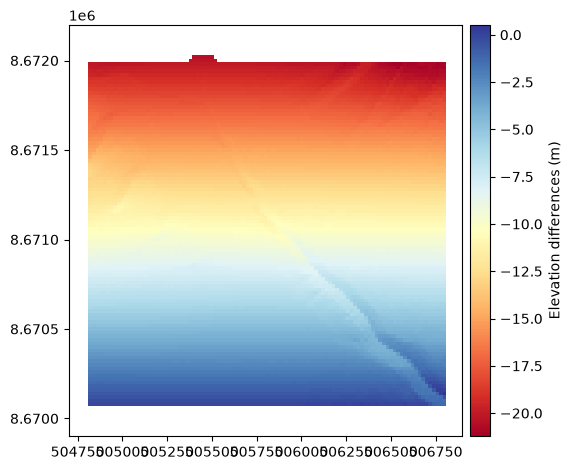

In [9]:
diff_before = dem - rotated_dem
diff_before.plot(cmap="RdYlBu", cbar_title="Elevation differences (m)")
plt.xlim(504700, 506900) 
plt.ylim(8669900, 8672200) 
plt.show()

When several rotations are combined, the rotation matrix can be really hard to compute. To do this, you can use the function :func:`~xdem.coreg.matrix_from_translations_rotations`. 

Here is an example of a rotation of 0.1 degree in X, 0.2 in Y and 0.3 in Z with the previous shifts `(shift_x, shift_z, shift_z)`.

In [6]:
matrix = xdem.coreg.matrix_from_translations_rotations(t1=shift_x, t2=shift_y, t3=shift_z, alpha1=0.1, alpha2=0.2, alpha3=0.3, use_degrees=True)
matrix

array([[ 9.99980200e-01, -5.22986361e-03,  3.49973673e-03,
         6.00000000e+01],
       [ 5.23593193e-03,  9.99984801e-01, -1.72702754e-03,
         1.00000000e+02],
       [-3.49065142e-03,  1.74531773e-03,  9.99992385e-01,
         2.00000000e+01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

                                            geometry
0  POLYGON ((504810 8670030, 504810 8670030.4, 50...
                                            geometry
0  POLYGON ((504810 8670030, 504810 8670030.4, 50...


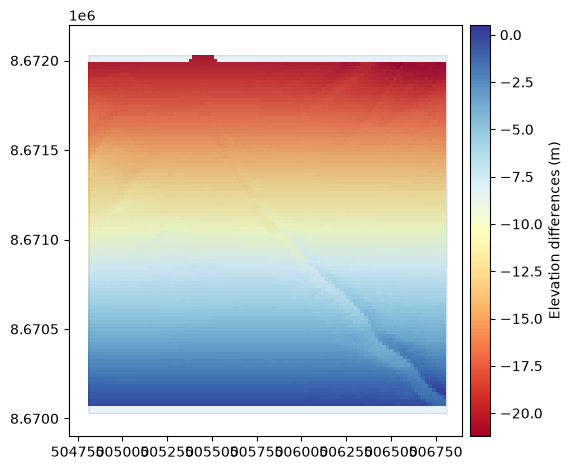

In [16]:
rotated_dem = xdem.coreg.apply_matrix(dem, matrix=matrix, centroid=centroid)
diff_before = dem - rotated_dem
diff_before.plot(cmap="RdYlBu", cbar_title="Elevation differences (m)")
rotated_dem.get_footprint_projected(dem.crs, densify_points=5000).plot(ec="k", alpha=0.1)
plt.xlim(504700, 506900) 
plt.ylim(8669900, 8672200) 
plt.show()

Even if a translation is applicated with a rotation, the transform and the footprint are the same before and after. 